In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.2 MB/s eta 0:00:00


1. Word2Vec Arithmetic — Vector arithmetic on pre-trained word embeddings

In [ ]:
import gensim.downloader as api
import numpy as np

# Load pre-trained word vectors
word_vectors = api.load("word2vec-google-news-300")

def vector_arithmetic(w1, w2, w3):
    """Perform w1 - w2 + w3 and show top 5 similar words."""
    try:
        result = word_vectors[w1] - word_vectors[w2] + word_vectors[w3]
        results = [(w, s) for w, s in word_vectors.similar_by_vector(result, topn=10)
                   if w not in {w1, w2, w3}][:5]
        print(f"\n{w1} - {w2} + {w3}:")
        for word, score in results:
            print(f"  {word}: {score:.4f}")
    except KeyError as e:
        print(f"Word not found: {e}")

def word_similarity(w1, w2):
    """Print cosine similarity between two words."""
    try:
        print(f"\nSimilarity({w1}, {w2}): {word_vectors.similarity(w1, w2):.4f}")
    except KeyError as e:
        print(f"Word not found: {e}")

def most_similar(word):
    """Print top 5 most similar words."""
    try:
        print(f"\nMost similar to '{word}':")
        for w, s in word_vectors.most_similar(word, topn=5):
            print(f"  {w}: {s:.4f}")
    except KeyError as e:
        print(f"Word not found: {e}")

# --- Run Examples ---
for args in [("king","man","woman"), ("paris","france","germany"), ("apple","fruit","carrot")]:
    vector_arithmetic(*args)

for pair in [("cat","dog"), ("computer","keyboard"), ("music","art")]:
    word_similarity(*pair)

for word in ["happy", "sad", "technology"]:
    most_similar(word)

[==================================================] 100.0% 1662.8/1662.8MB downloaded

king - man + woman:
  queen: 0.7301
  monarch: 0.6455
  princess: 0.6156
  crown_prince: 0.5819
  prince: 0.5777

paris - france + germany:
  berlin: 0.4838
  german: 0.4695
  lindsay_lohan: 0.4536
  switzerland: 0.4468
  heidi: 0.4445

apple - fruit + carrot:
  carrots: 0.5700
  proverbial_carrot: 0.4578
  Carrot: 0.4159
  Twizzler: 0.4074
  peppermint_candy: 0.4074

Similarity(cat, dog): 0.7609

Similarity(computer, keyboard): 0.3964

Similarity(music, art): 0.4010

Most similar to 'happy':
  glad: 0.7409
  pleased: 0.6632
  ecstatic: 0.6627
  overjoyed: 0.6599
  thrilled: 0.6514

Most similar to 'sad':
  saddening: 0.7273
  Sad: 0.6611
  saddened: 0.6604
  heartbreaking: 0.6574
  disheartening: 0.6507

Most similar to 'technology':
  technologies: 0.8332
  innovations: 0.6231
  technological_innovations: 0.6102
  technol: 0.6047
  technological_advancement: 0.6036


2. Embedding Visualization — PCA/t-SNE visualization of word embedding relationships &
Domain Word Clustering — Tech domain word embeddings with semantic similarity


king - man + woman:
  queen: 0.7301
  monarch: 0.6455
  princess: 0.6156
  crown_prince: 0.5819
  prince: 0.5777


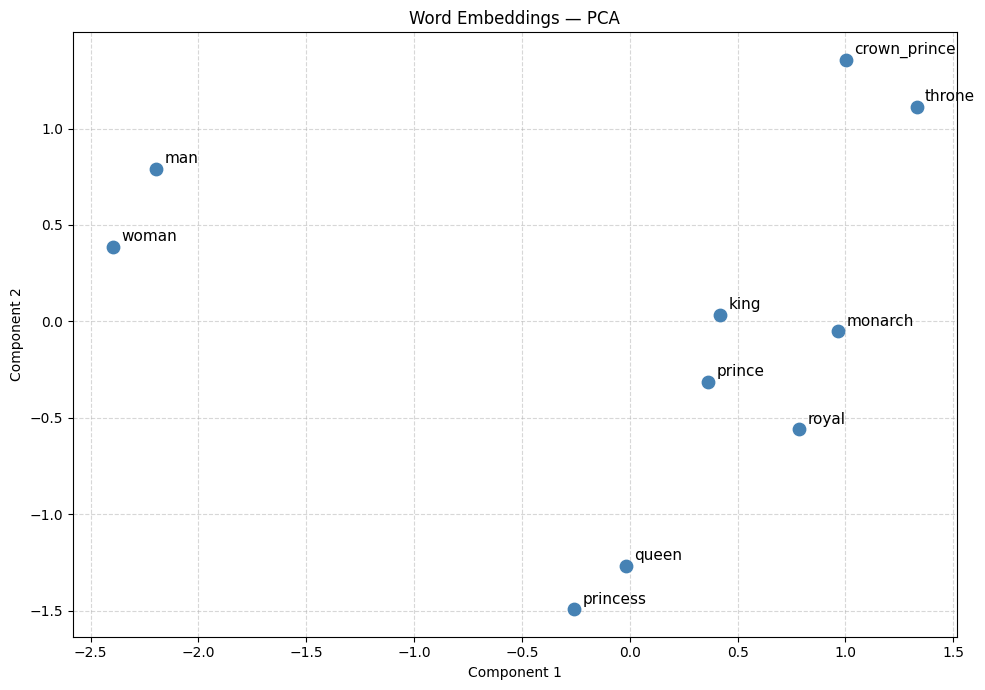

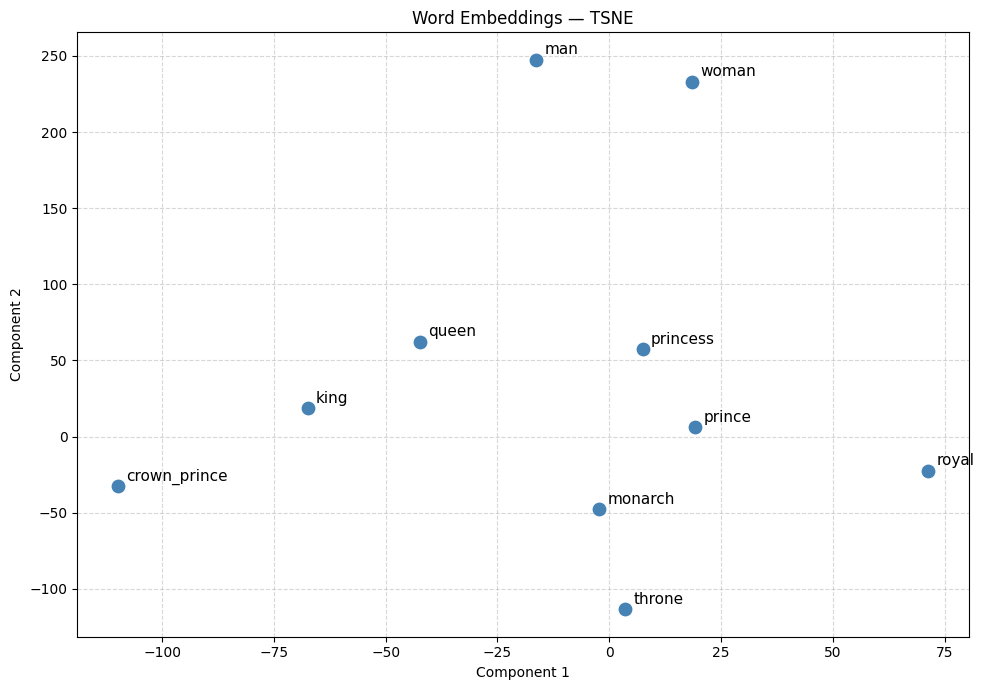

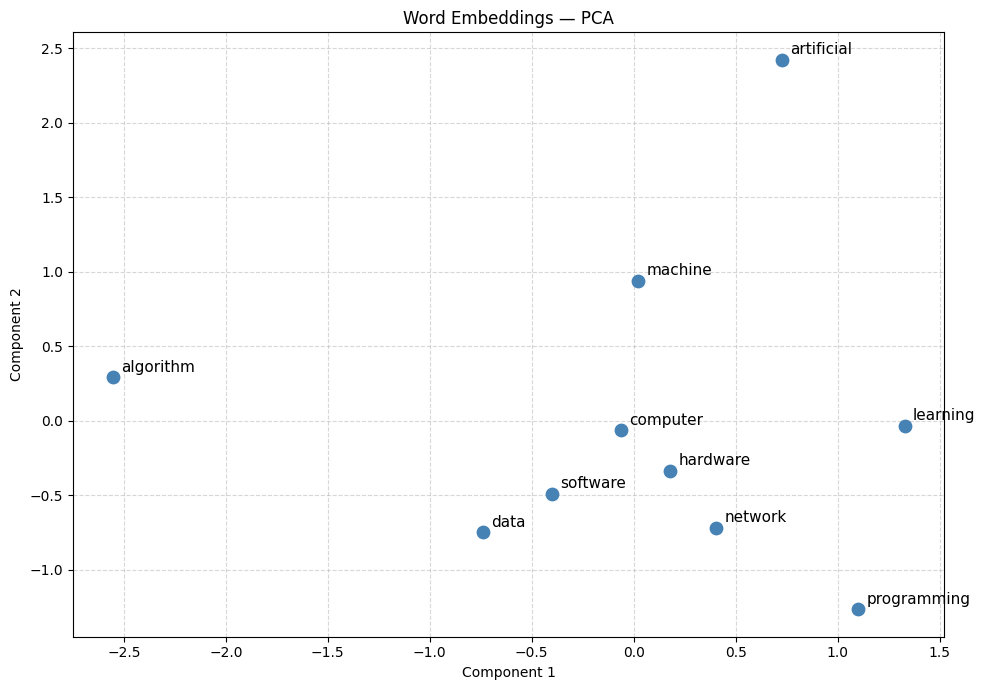

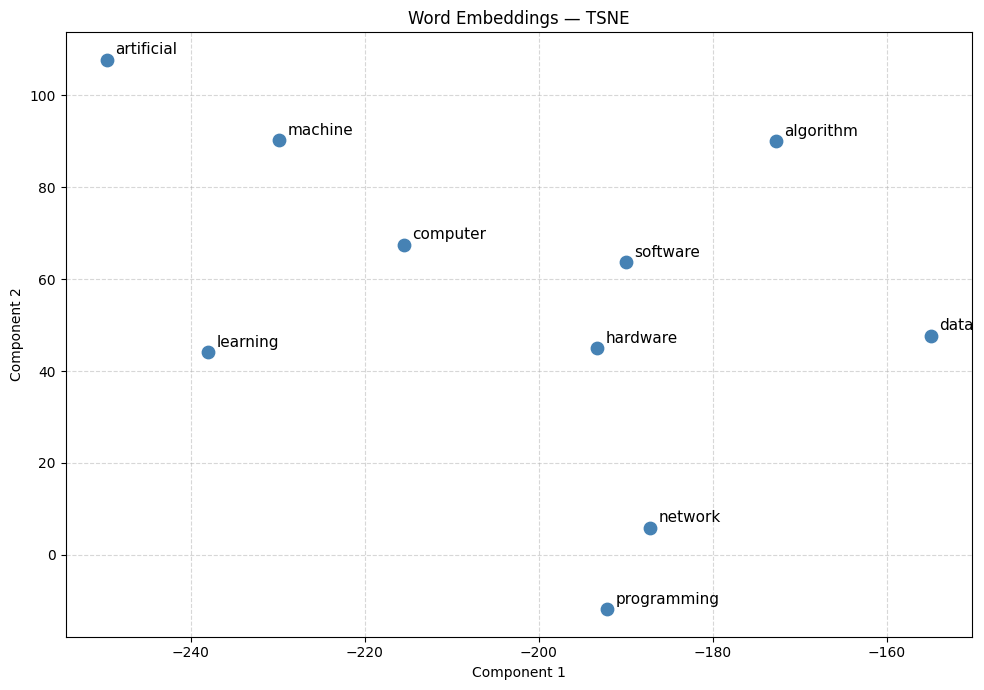


Top 5 similar to 'computer':
  computers: 0.7979
  laptop: 0.6640
  laptop_computer: 0.6549
  Computer: 0.6473
  com_puter: 0.6082

Top 5 similar to 'learning':
  teaching: 0.6602
  learn: 0.6365
  Learning: 0.6208
  reteaching: 0.5810
  learner_centered: 0.5739


In [ ]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load model once
word_vectors = api.load("word2vec-google-news-300")

# ── Helpers ──────────────────────────────────────────────────────────────────

def vector_arithmetic(w1, w2, w3):
    """w1 - w2 + w3 → top 5 similar words (excluding inputs)."""
    try:
        result = word_vectors[w1] - word_vectors[w2] + word_vectors[w3]
        hits = [(w, s) for w, s in word_vectors.similar_by_vector(result, topn=10)
                if w not in {w1, w2, w3}][:5]
        print(f"\n{w1} - {w2} + {w3}:")
        for w, s in hits: print(f"  {w}: {s:.4f}")
        return [w for w, _ in hits]
    except KeyError as e:
        print(f"Word not found: {e}"); return []

def visualize(words, vectors, method="pca", perplexity=3):
    """Reduce to 2-D with PCA or t-SNE and scatter-plot."""
    reducer = (PCA(n_components=2) if method == "pca"
               else TSNE(n_components=2, random_state=42, perplexity=perplexity))
    coords = reducer.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1], color="steelblue", s=80, zorder=3)
    for i, word in enumerate(words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]),
                     textcoords="offset points", xytext=(6, 4), fontsize=11)
    plt.title(f"Word Embeddings — {method.upper()}")
    plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()

def similar_words(word, topn=5):
    """Print top-N semantically similar words."""
    try:
        print(f"\nTop {topn} similar to '{word}':")
        for w, s in word_vectors.most_similar(word, topn=topn):
            print(f"  {w}: {s:.4f}")
    except KeyError as e:
        print(f"Word not found: {e}")

def get_vectors(words):
    return np.array([word_vectors[w] for w in words])

# ── Part (a): Vector arithmetic + visualize results ───────────────────────────

base_words   = ["king", "man", "woman", "queen", "prince", "princess", "royal", "throne"]
result_words = vector_arithmetic("king", "man", "woman")
all_words    = list(dict.fromkeys(base_words + result_words))   # preserve order, no dupes

for method in ("pca", "tsne"):
    visualize(all_words, get_vectors(all_words), method=method)

# ── Part (b): Domain words + semantic similarity ──────────────────────────────

tech_words = ["computer", "software", "hardware", "algorithm", "data",
              "network", "programming", "machine", "learning", "artificial"]

for method in ("pca", "tsne"):
    visualize(tech_words, get_vectors(tech_words), method=method)

for word in ("computer", "learning"):
    similar_words(word)

3. Custom Word2Vec — Training domain-specific embeddings on medical corpus

Training Word2Vec model...
Model training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


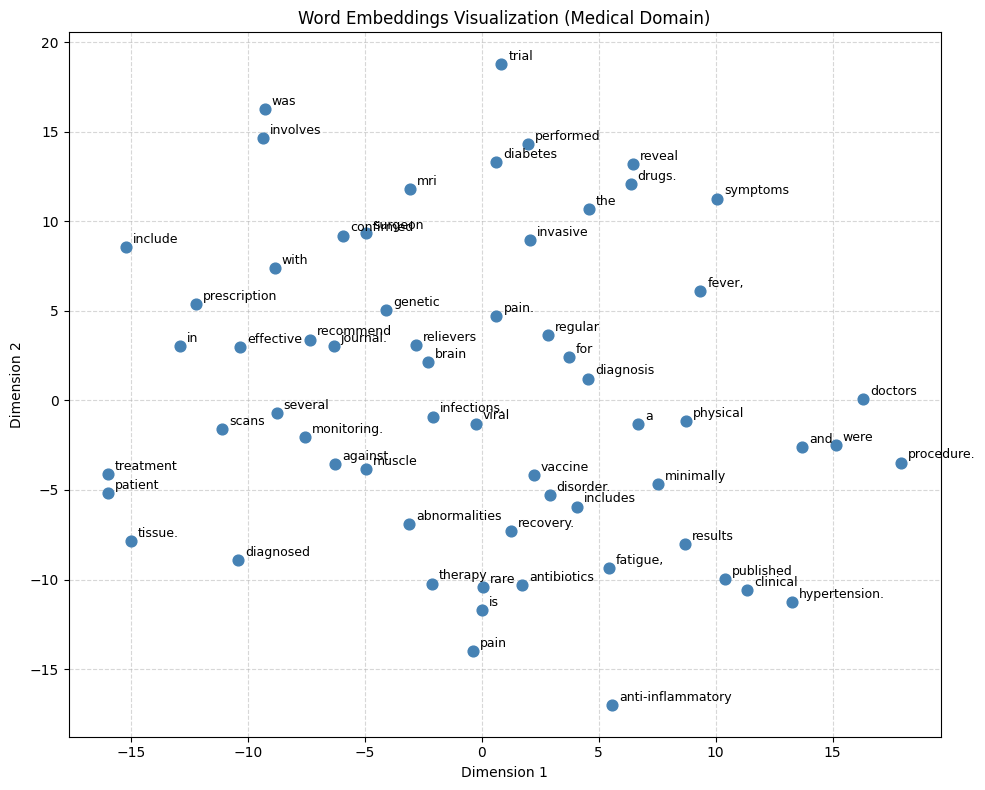


Words similar to 'treatment':
  patient (0.25)
  pain. (0.14)
  brain (0.12)
  against (0.11)
  muscle (0.11)

Words similar to 'vaccine':
  disorder. (0.20)
  tissue. (0.14)
  recovery. (0.12)
  therapy (0.10)
  doctors (0.09)


In [ ]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Corpus
medical_corpus = [
    "The patient was diagnosed with diabetes and hypertension.",
    "MRI scans reveal abnormalities in the brain tissue.",
    "The treatment involves antibiotics and regular monitoring.",
    "Symptoms include fever, fatigue, and muscle pain.",
    "The vaccine is effective against several viral infections.",
    "Doctors recommend physical therapy for recovery.",
    "The clinical trial results were published in the journal.",
    "The surgeon performed a minimally invasive procedure.",
    "The prescription includes pain relievers and anti-inflammatory drugs.",
    "The diagnosis confirmed a rare genetic disorder."
]

# Preprocess & Train
print("Training Word2Vec model...")
model = Word2Vec(
    sentences=[s.lower().split() for s in medical_corpus],
    vector_size=100, window=5, min_count=1, workers=4, epochs=50
)
print("Model training complete!")

# Extract embeddings
words = list(model.wv.index_to_key)
embeddings = np.array([model.wv[w] for w in words])

# Dimensionality reduction using t-SNE
tsne_result = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=300) \
                  .fit_transform(embeddings)

# Visualization
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], color="steelblue", s=60, zorder=3)
for i, word in enumerate(words):
    plt.annotate(word, (tsne_result[i, 0], tsne_result[i, 1]),
                 textcoords="offset points", xytext=(5, 3), fontsize=9)
plt.title("Word Embeddings Visualization (Medical Domain)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Semantic similarity
def find_similar_words(input_word, top_n=5):
    try:
        print(f"\nWords similar to '{input_word}':")
        for word, similarity in model.wv.most_similar(input_word, topn=top_n):
            print(f"  {word} ({similarity:.2f})")
    except KeyError:
        print(f"'{input_word}' not found in vocabulary.")

# Example
find_similar_words("treatment")
find_similar_words("vaccine")

4. Prompt Enrichment (Word embedding-based GenAI prompt enhancement)

In [ ]:
import gensim.downloader as api
from transformers import pipeline
from nltk.tokenize import word_tokenize
import nltk, string

nltk.download('punkt_tab')

# Load models
word_vectors = api.load("glove-wiki-gigaword-100")
generator    = pipeline("text-generation", model="gpt2")

def enrich_prompt(prompt, keyword, topn=1):
    """Replace keyword in prompt with its most similar word from embeddings."""
    words = word_tokenize(prompt)
    enriched = []
    for word in words:
        cleaned = word.lower().strip(string.punctuation)
        if cleaned == keyword.lower():
            try:
                replacement = word_vectors.most_similar(cleaned, topn=topn)[0][0]
                print(f"Replacing '{word}' → '{replacement}'")
                enriched.append(replacement); continue
            except KeyError:
                print(f"'{keyword}' not found in vocabulary.")
        enriched.append(word)
    enriched_prompt = " ".join(enriched)
    print(f"\nEnriched Prompt: {enriched_prompt}")
    return enriched_prompt

def generate_response(prompt, max_length=100):
    try:
        return generator(prompt, max_length=max_length, num_return_sequences=1)[0]['generated_text']
    except Exception as e:
        print(f"Error: {e}"); return None

# Run
original_prompt  = "Who is king."
enriched_prompt  = enrich_prompt(original_prompt, keyword="king")

original_response = generate_response(original_prompt)
enriched_response = generate_response(enriched_prompt)

# Compare
print("\nOriginal Prompt Response:\n",  original_response)
print("\nEnriched Prompt Response:\n",  enriched_response)
print("\n--- Comparison ---")
print(f"Response Length  — Original: {len(original_response)} | Enriched: {len(enriched_response)}")
print(f"Sentence Count   — Original: {original_response.count('.')} | Enriched: {enriched_response.count('.')}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[==================================================] 100.0% 128.1/128.1MB downloaded


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Replacing 'king' → 'prince'

Enriched Prompt: Who is prince .


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Original Prompt Response:
 Who is king. How can he be king?

And when you say that, you may think that you are telling the truth.

And when you say that, you may think that you are telling the truth.

So you say:

I am king. I am king.

Well, if you are a king, what do you think you are doing?

Well, if you are a king, what do you think you are doing?

You don't have to give up. You don't have to give up.

The truth is that you are not telling the truth.

The truth is that you are not telling the truth.

You do not have to give up. You do not have to give up.

The truth is that you are not telling the truth.

You do not have to give up. You do not have to give up.

I am king. I am king.

Well, if you are a king, what do you think you are doing?

Well, if you are a king, what do you think you are doing?

You don't have to give up. You don't have to give up.

The truth is

Enriched Prompt Response:
 Who is prince ...?

(In English.)

If you are prince...

(In English.)

The prince...

(

5. Creative Text Generation — Seed-word paragraph generation using GloVe embeddings

In [ ]:
import gensim.downloader as api
import random

word_vectors = api.load("glove-wiki-gigaword-100")

def get_similar_words(seed, top_n=5):
    try:
        return [w for w, _ in word_vectors.most_similar(seed, topn=top_n)]
    except KeyError:
        print(f"'{seed}' not found in vocabulary."); return []

def generate_paragraph(seed):
    sim = get_similar_words(seed)
    if not sim:
        return "Could not generate a paragraph. Try another seed word."

    templates = [
        f"The {seed} was surrounded by {sim[0]} and {sim[1]}.",
        f"People often associate {seed} with {sim[2]} and {sim[3]}.",
        f"In the land of {seed}, {sim[4]} was a common sight.",
        f"A story about {seed} would be incomplete without {sim[1]} and {sim[3]}.",
    ]
    return " ".join(random.choice(templates) for _ in range(4))

# Run
seed = input("Enter a seed word: ")
print("\nGenerated Paragraph:\n", generate_paragraph(seed))

Enter a seed word: ocean

Generated Paragraph:
 People often associate ocean with seas and coast. A story about ocean would be incomplete without waters and coast. The ocean was surrounded by sea and waters. In the land of ocean, atlantic was a common sight.


6. Sentiment Analysis — Customer review sentiment using HuggingFace pipeline

In [ ]:
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis")

def analyze_sentiment(text):
    result = sentiment_analyzer(text)[0]
    print(f"Input: {text}")
    print(f"Sentiment: {result['label']} (Confidence: {result['score']:.4f})\n")
    return result

customer_reviews = [
    "The product is amazing! I love it so much.",
    "I'm very disappointed. The service was terrible.",
    "It was an average experience, nothing special.",
    "Absolutely fantastic quality! Highly recommended.",
    "Not great, but not the worst either."
]

for review in customer_reviews:
    analyze_sentiment(review)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Input: The product is amazing! I love it so much.
Sentiment: POSITIVE (Confidence: 0.9999)

Input: I'm very disappointed. The service was terrible.
Sentiment: NEGATIVE (Confidence: 0.9998)

Input: It was an average experience, nothing special.
Sentiment: NEGATIVE (Confidence: 0.9995)

Input: Absolutely fantastic quality! Highly recommended.
Sentiment: POSITIVE (Confidence: 0.9999)

Input: Not great, but not the worst either.
Sentiment: NEGATIVE (Confidence: 0.9961)



7. Text Summarization — Multi-strategy BART summarization with LangChain

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
model     = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

def summarize(text, **kwargs):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    output = model.generate(**inputs, **kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

def summarize_text(text):
    text = " ".join(text.split())
    configs = {
        "Default":          dict(max_new_tokens=150, do_sample=False),
        "High Randomness":  dict(max_new_tokens=150, do_sample=True, temperature=0.9),
        "Conservative":     dict(max_new_tokens=150, do_sample=False, num_beams=5),
        "Diverse Sampling": dict(max_new_tokens=150, do_sample=True, top_k=50, top_p=0.95),
    }
    print(f"Original Text:\n{text}\n")
    for label, kwargs in configs.items():
        print(f"{label}: {summarize(text, **kwargs)}\n")

long_text = """
Artificial Intelligence (AI) is a rapidly evolving field of computer science focused on creating
intelligent machines capable of mimicking human cognitive functions such as learning, problem-solving,
and decision-making. In recent years, AI has significantly impacted various industries, including
healthcare, finance, education, and entertainment. AI-powered applications, such as chatbots,
self-driving cars, and recommendation systems, have transformed the way we interact with technology.
Machine learning and deep learning, subsets of AI, enable systems to learn from data and improve over
time without explicit programming. However, AI also poses ethical challenges, such as bias in
decision-making and concerns over job displacement. As AI technology continues to advance, it is
crucial to balance innovation with ethical considerations to ensure its responsible development and
deployment.
"""

summarize_text(long_text)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Original Text:
Artificial Intelligence (AI) is a rapidly evolving field of computer science focused on creating intelligent machines capable of mimicking human cognitive functions such as learning, problem-solving, and decision-making. In recent years, AI has significantly impacted various industries, including healthcare, finance, education, and entertainment. AI-powered applications, such as chatbots, self-driving cars, and recommendation systems, have transformed the way we interact with technology. Machine learning and deep learning, subsets of AI, enable systems to learn from data and improve over time without explicit programming. However, AI also poses ethical challenges, such as bias in decision-making and concerns over job displacement. As AI technology continues to advance, it is crucial to balance innovation with ethical considerations to ensure its responsible development and deployment.

Default: Artificial Intelligence (AI) is a rapidly evolving field of computer science 

8. Document Analysis (Google Drive document summarization and sentiment analysis using Cohere + LangChain)

In [ ]:
!pip install langchain-cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: cohere
    Found existing installation: cohere 6.1.0
    Uninstalling cohere-6.1.0:
      Successfully uninstalled cohere-6.1.0


In [ ]:
!pip install cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 28.1 MB/s eta 0:00:00


In [13]:
import getpass
from langchain_core.prompts import PromptTemplate
from langchain_cohere import ChatCohere
from google.colab import auth, drive

# Auth & mount
auth.authenticate_user()
drive.mount('/content/drive')

# Load file
with open("/content/drive/My Drive/Teaching.txt", "r", encoding="utf-8") as f:
    text_content = f.read()

# LLM setup
cohere_llm = ChatCohere(
    cohere_api_key=getpass.getpass("Enter Cohere API Key: "),
    model="command-a-03-2025"
)

# Prompt template
template = """
You are an AI assistant helping to summarize and analyze a text document.
Here is the document content:

{text}

Summary:
- Provide a concise summary of the document.

Key Takeaways:
- List 3 important points from the text.

Sentiment Analysis:
- Determine if the sentiment is Positive, Negative, or Neutral.
"""

prompt = PromptTemplate(input_variables=["text"], template=template)

chain    = prompt | cohere_llm
response = chain.invoke({"text": text_content})
print(response.content)                      # ✅ .content for AIMessage

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter Cohere API Key: ··········
### **Summary:**

The document introduces machine learning (ML) as a subset of artificial intelligence that enables systems to learn and improve from experience without explicit programming. It outlines the three main types of ML: supervised learning (using labeled data for predictions), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (training agents through rewards and penalties). The text highlights various real-world applications of ML across industries like healthcare, finance, education, and retail. It also discusses challenges such as data quality, overfitting, interpretability, and bias. The conclusion emphasizes ML's transformative potential while stressing the need for ethical and responsible development.

---

### **Key Takeaways:**

1. **Three Types of Machine Learning:** Supe

9. Institution Extractor — Wikipedia-based institution detail fetcher with Pydantic


In [ ]:
!pip install wikipedia-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 8.4 MB/s eta 0:00:00


In [6]:
from pydantic import BaseModel
from typing import List, Optional
import wikipediaapi

class InstitutionDetails(BaseModel):
    founder:             Optional[str]       = None
    founded:             Optional[str]       = None
    branches:            Optional[List[str]] = None
    number_of_employees: Optional[int]       = None
    summary:             Optional[str]       = None

def fetch_institution_details(name: str) -> InstitutionDetails:
    wiki  = wikipediaapi.Wikipedia("MyApp/1.0", language="en")
    page  = wiki.page(name)
    if not page.exists():
        raise ValueError(f"'{name}' not found on Wikipedia.")

    founder = founded = number_of_employees = None
    branches = []

    for line in page.text.split('\n'):
        if 'Founder'             in line: founder             = line.split(':')[-1].strip()
        elif 'Founded'           in line: founded             = line.split(':')[-1].strip()
        elif 'Branches'          in line: branches            = [b.strip() for b in line.split(':')[-1].split(',')]
        elif 'Number of employees' in line:
            try:    number_of_employees = int(line.split(':')[-1].strip().replace(',', ''))
            except: pass

    return InstitutionDetails(
        founder=founder, founded=founded,
        branches=branches or None,
        number_of_employees=number_of_employees,
        summary=page.summary[:500]
    )

def display_details(d: InstitutionDetails):
    print(f"Founder:     {d.founder             or 'N/A'}")
    print(f"Founded:     {d.founded             or 'N/A'}")
    print(f"Branches:    {', '.join(d.branches) if d.branches else 'N/A'}")
    print(f"Employees:   {d.number_of_employees or 'N/A'}")
    print(f"Summary:     {d.summary             or 'N/A'}")

# Run
try:
    display_details(fetch_institution_details(input("Enter institution name: ")))
except ValueError as e:
    print(e)

Enter institution name: Google
Founder:   N/A
Founded:   N/A
Branches:  N/A
Employees: N/A
Summary:   Google LLC ( , GOO-gəl) is an American multinational technology corporation focused on information technology, online advertising, search engine technology, email, cloud computing, software, quantum computing, e-commerce, consumer electronics, and artificial intelligence (AI). It has been referred to as "the most powerful company in the world" by the BBC, and is one of the world's most valuable brands. Google's parent company Alphabet Inc. has been described as a Big Tech company. 
Google was fo


10. IPC Chatbot — Indian Penal Code Q&A chatbot using Cohere + LangChain

In [12]:
import getpass
import wikipediaapi
from pydantic import BaseModel
from typing import Optional
from langchain_core.prompts import PromptTemplate
from langchain_cohere import ChatCohere

# Setup
COHERE_API_KEY = getpass.getpass("Enter your Cohere API Key: ")
cohere_llm     = ChatCohere(cohere_api_key=COHERE_API_KEY, model="command-a-03-2025")

# Fetch IPC content
wiki = wikipediaapi.Wikipedia(language="en", user_agent="IPCChatbot/1.0")
page = wiki.page("Indian Penal Code")
if not page.exists():
    raise ValueError("Indian Penal Code page not found on Wikipedia.")
ipc_content = page.text[:5000]

# Pydantic response model
class IPCResponse(BaseModel):
    section:     Optional[str] = None
    explanation: Optional[str] = None

# Prompt template
prompt_template = PromptTemplate(
    input_variables=["ipc_content", "question"],
    template="""
You are a legal assistant chatbot specialized in the Indian Penal Code (IPC).
Refer to the following IPC content to answer the query:

{ipc_content}

User Question: {question}
Provide a detailed answer, mentioning the relevant section if applicable.
"""
)

def get_ipc_response(question: str) -> IPCResponse:
    chain    = prompt_template | cohere_llm
    response = chain.invoke({"ipc_content": ipc_content, "question": question})
    text     = response.content
    if "Section" in text:
        return IPCResponse(
            section=text.split("Section")[1].split(":")[0].strip(),
            explanation=text.split(":", 1)[-1].strip()
        )
    return IPCResponse(explanation=text.strip())

# Chat loop
print("IPC Chatbot — type 'exit' to quit\n")
while True:
    question = input("You: ")
    if question.lower() == "exit":
        break
    try:
        r = get_ipc_response(question)
        print(f"Section:     {r.section or 'N/A'}")
        print(f"Explanation: {r.explanation}\n")
    except Exception as e:
        print(f"Error: {e}")

Enter your Cohere API Key: ··········
IPC Chatbot — type 'exit' to quit

You: give a summary
Section:     377**, which criminalized "carnal intercourse against the order of nature" with penalties including imprisonment for life or up to ten years, along with a fine. The section was interpreted to include same-sex relations. Key legal developments regarding
Explanation: 1. **2009 Delhi High Court Judgment**: The court ruled that Section 377 could not be used to criminalize consensual same-sex relations, marking a liberal interpretation.  
2. **2013 Supreme Court Judgment**: The Supreme Court overturned the Delhi High Court's decision, upholding Section 377 as constitutional and stating that any change should come from the legislature.  
3. **2018 Supreme Court Reconsideration**: The Supreme Court decriminalized consensual same-sex relations, striking down parts of Section 377 that criminalized such acts, in a landmark judgment.  

The IPC's structure was comprehensive, covering offenses